## Synopsis


We examine properties of n-dimensional vector spaces over $\mathbb{R}$.
What yields from normed vectors spaces study it suffices to learn of properties of unit balls centered at zero.

We sample uniform random variables $X^n,Y^n \in \mathbb{R}^n$ from the unit ball given a metric from $\mathcal{l}_p$
* $E[||X^n||_p]$
* $E[||X^n-Y^n||_p]$
* Volume of unit ball given norm $\mathcal{l}_p$



#### Imports and global configs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from typing import Callable, TypeAlias
from functools import partial
import time
from tqdm import tqdm

with tqdm(total=10) as pbar:
    for i in range(10):
        pbar.update(1)
        time.sleep(0.01)


# config
rng = np.random.default_rng()
random_sample = lambda sample_size: np.random.random_sample(sample_size) * 2 - 1
print_delimiter = lambda: print("=" * 130)
def log_stdout(fmt):
    # if random_sample() < 0.33:
    #     print(fmt, flush=False)
    pass

100%|██████████| 10/10 [00:00<00:00, 95.07it/s]


# Random samples source

### What
Sample uniformly distributed points from n dimensional unit ball

### How
We achieve uniform distribution by sampling points from truly uniform n dimensional square $S$ with corners at $\big((-1)^{a_i}\big)_{i\in [n]}, a_i = \{0, 1\}$

##### Caveats
This sampling process for small $p$'s and big $n$'s becomes time-consuming
The $S$ becomes larger in an exponential rate, on top of that, the unit balls seem to actually shrink when $n$ grows

> formula for volume of a n-dimensional ball of radius R:
>
> $V_n(R) = \begin{cases}
1 &\text{if } n=0,\\[0.5ex]
2R &\text{if } n=1,\\[0.5ex]
\dfrac{2\pi}{n}R^2 \times V_{n-2}(R) &\text{otherwise}.
\end{cases}
$


In [2]:
def pivot_with_mask(vec: np.ndarray, mask: np.ndarray):
    """expects 2dim vector array"""

    size = mask.sum()
    new_samples = random_sample(size * vec.shape[1]).reshape(size, vec.shape[1])
    vec[mask] = new_samples
    vec[:] = np.concatenate((vec[~mask], new_samples))


def generate_samples(quantity: int = 10, dimension: int = 2, p_norm: int | float = 2) -> np.ndarray:
    """Generate random points in a unit ball of given dimension."""

    def p_norm_to_p(_vec):
        """calculates (||vec||_p) ^ p"""
        return np.power(np.abs(_vec), p_norm).sum(axis=-1)

    sample_vec = random_sample(quantity * dimension).reshape((quantity, dimension))

    current_total = 0
    log_stdout(f"Generating samples for quantity={quantity}, dimension={dimension}, p_norm={p_norm}")
    with tqdm(total=quantity) as pbar:
        while np.any(mask := (p_norm_to_p(sample_vec) >= 1.0)):
            delta = quantity - mask.sum() - current_total
            pbar.update(delta)
            current_total += delta
            pivot_with_mask(sample_vec, mask)

        pbar.update(quantity-current_total)

    return sample_vec.reshape(quantity, dimension)

In [3]:
def estimated_difference_value(number_of_samples: int, dimensions: int = 2, p_norm = 2, repeats: int = 100) -> np.ndarray:
    """use p norm to calculate distance between two points."""

    if number_of_samples % 2 == 1:
        number_of_samples += 1

    samples = generate_samples(number_of_samples * repeats, dimensions, p_norm)

    paired = samples.reshape(repeats, number_of_samples // 2, 2, dimensions)
    return np.linalg.norm(paired[:, :, 0] - paired[:, :, 1], ord=p_norm, axis=-1).mean(axis=-1)

In [4]:
estimated_difference_value(4, 8, 1, repeats=10)

100%|██████████| 40/40 [00:10<00:00,  3.95it/s]


array([1.604689  , 1.37867313, 1.24351669, 1.30716342, 1.32012308,
       1.42019228, 1.32668453, 1.33291973, 1.18606235, 1.12436835])

# $p\uparrow$ - Calculating $E[||X-Y||_p]$ for increasing $p$'s

100%|██████████| 50/50 [00:00<00:00, 48545.19it/s]


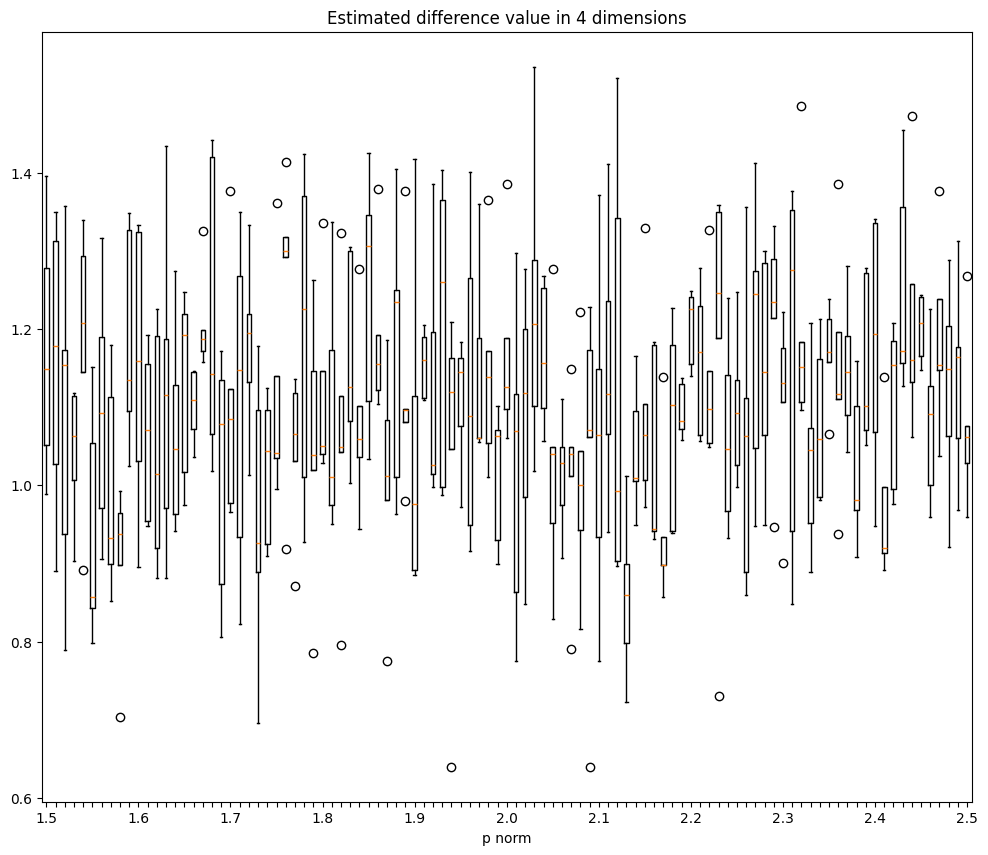

100%|██████████| 150/150 [00:00<00:00, 217622.14it/s]


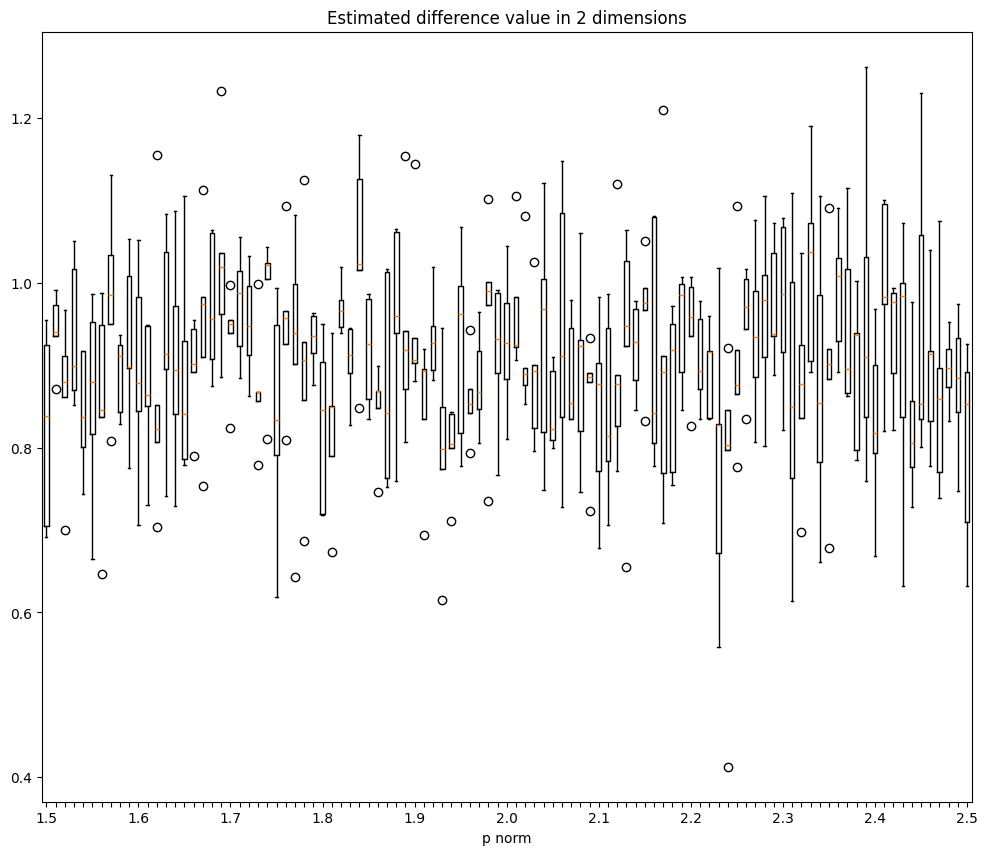

In [6]:
from typing import Iterable, Sequence


def generate_plot_against_p(number_of_samples: int, dimensions: int, p_values: Sequence, repeats: int):
    result_estimates = np.array([
        estimated_difference_value(number_of_samples=number_of_samples, dimensions=dimensions, p_norm=p_norm, repeats=repeats)
        for p_norm in p_values
    ])
    plt.figure(figsize=(12, 10))
    plt.title(f"Estimated difference value in {dimensions} dimensions")
    plt.xlabel("p norm")
    plt.boxplot(result_estimates.T, tick_labels=[f"{p_norm:.2}" if (index + 1) % 10 == len(p_values) % 10 or index==0 or p_norm == 2.0 else "" for index, p_norm in enumerate(p_values)], showfliers=True, showbox=True)
    plt.show()


dims_linspace = lambda start, stop, num: np.union1d(np.linspace(start, stop, num, endpoint=True), [2.0])
dimensions = 15
p_norms = [round(val, 3) for val in dims_linspace(1.5, 2.5, 100)]
generate_plot_against_p(number_of_samples=10, dimensions=4, p_values=p_norms, repeats=5)
generate_plot_against_p(number_of_samples=30, dimensions=2, p_values=p_norms, repeats=5)




Dimension: 1, p_values: 1.0-6.0


100%|██████████| 360/360 [00:00<00:00, 2351946.17it/s]


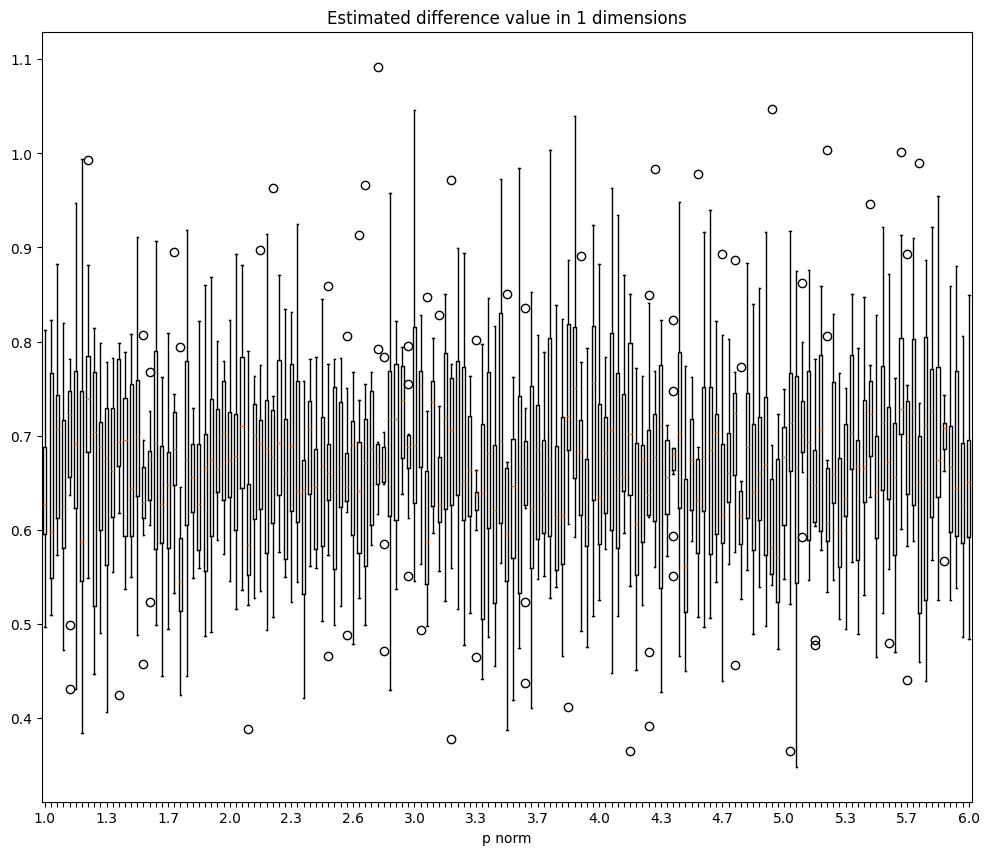

100%|██████████| 1000/1000 [00:00<00:00, 2886651.07it/s]


p=Max -> 0.6924479538979058


100%|██████████| 1000/1000 [00:00<00:00, 5108774.67it/s]


p=2 -> 0.6930960372253335

Dimension: 2, p_values: 1.0-6.0


100%|██████████| 360/360 [00:00<00:00, 458811.74it/s]


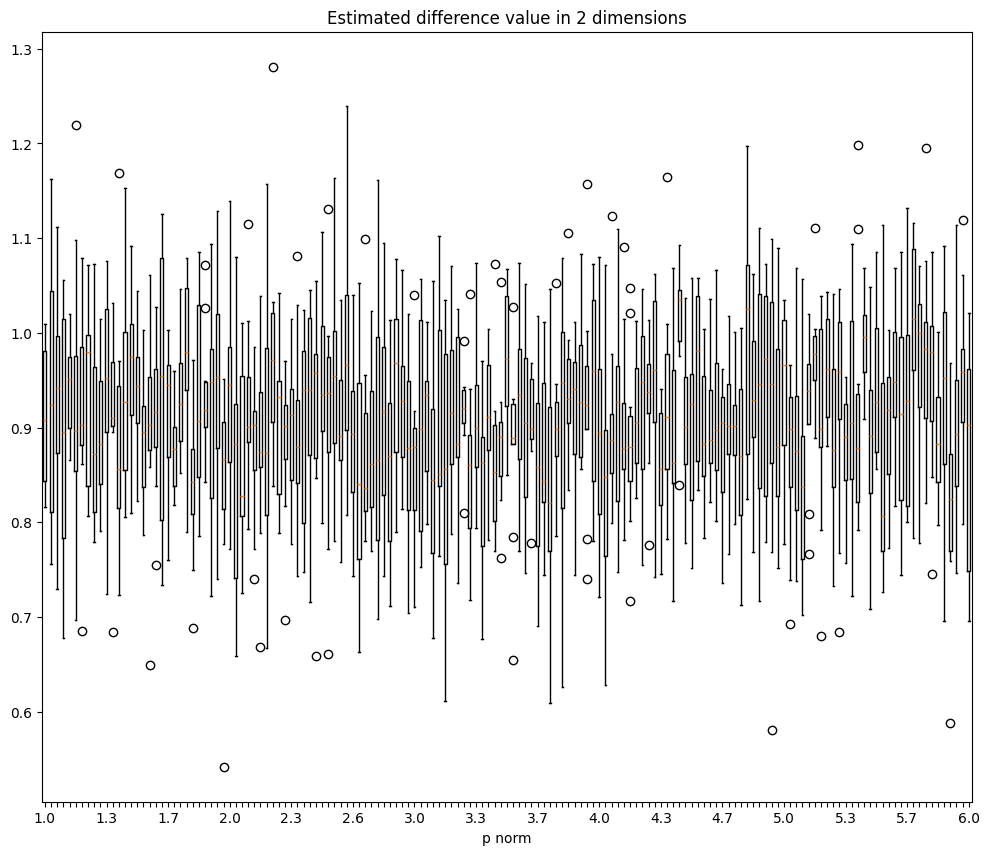

100%|██████████| 1000/1000 [00:00<00:00, 1544863.35it/s]


p=Max -> 0.9404336569316766


100%|██████████| 1000/1000 [00:00<00:00, 515080.93it/s]


p=2 -> 0.911760505925691

Dimension: 3, p_values: 1.0-6.0


100%|██████████| 360/360 [00:00<00:00, 442022.67it/s]


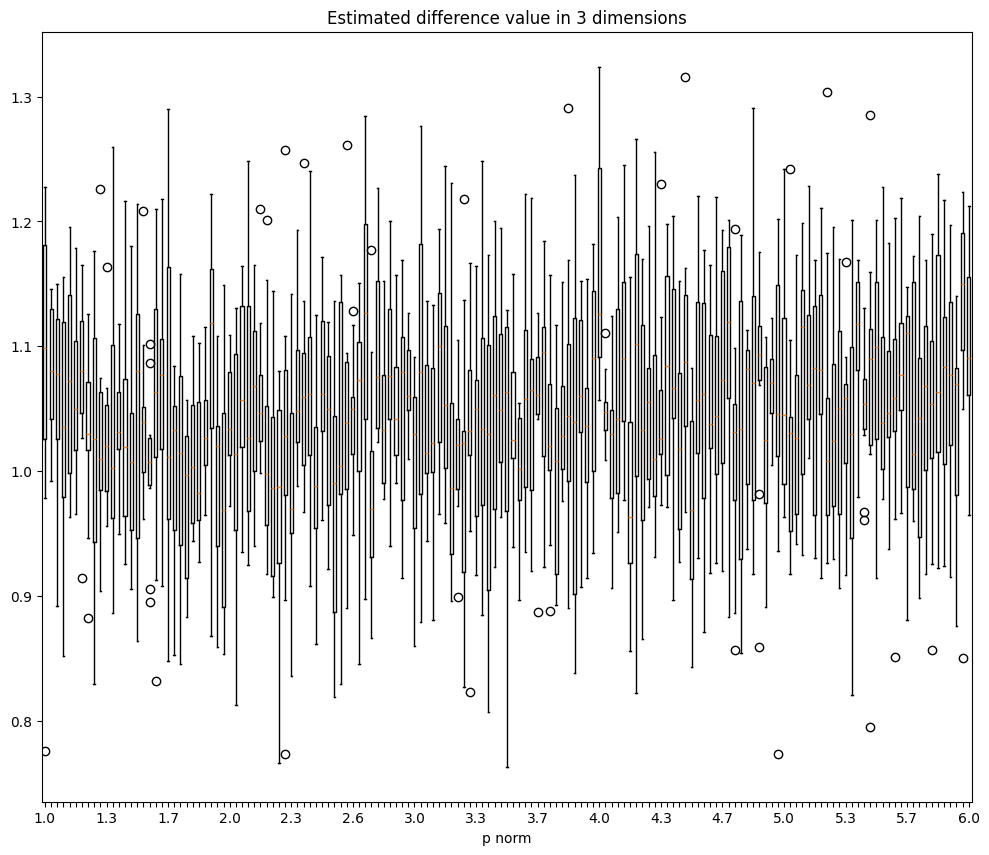

100%|██████████| 1000/1000 [00:00<00:00, 1910844.65it/s]


p=Max -> 1.04595235108903


100%|██████████| 1000/1000 [00:00<00:00, 303649.03it/s]


p=2 -> 1.0107576208659286

Dimension: 4, p_values: 1.0-6.0


100%|██████████| 360/360 [00:00<00:00, 240055.55it/s]


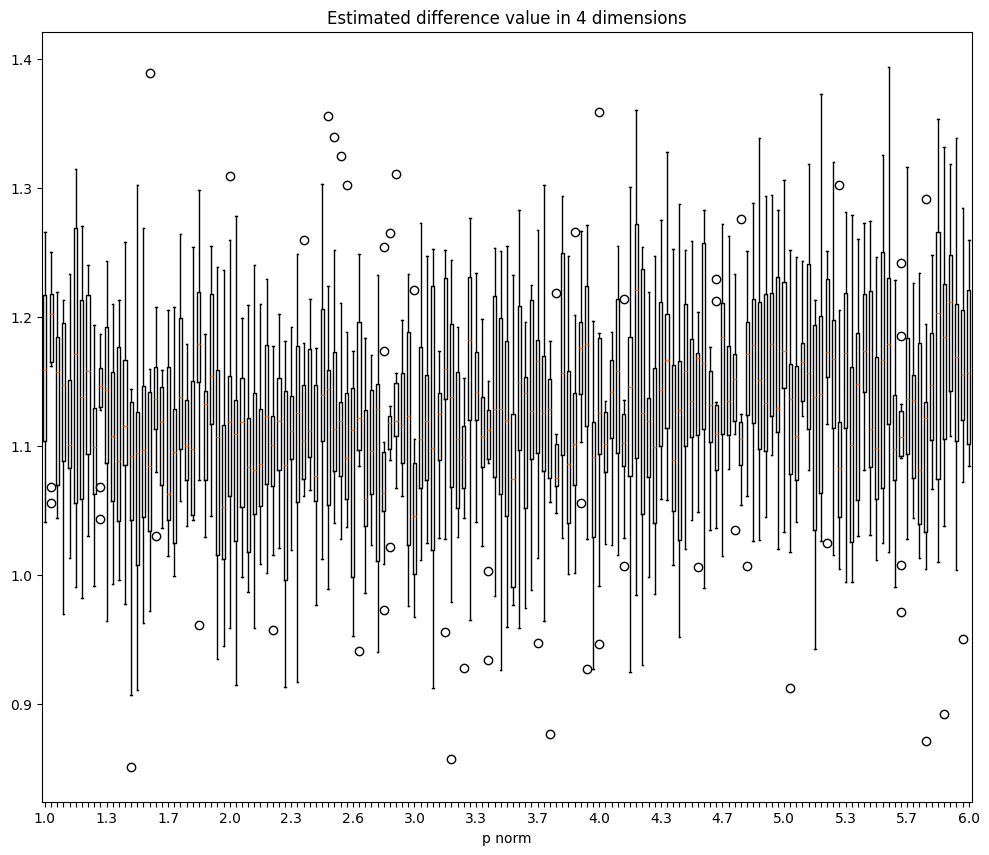

100%|██████████| 1000/1000 [00:00<00:00, 1664406.35it/s]


p=Max -> 1.1807733557567857


100%|██████████| 1000/1000 [00:00<00:00, 190191.99it/s]


p=2 -> 1.0758192134260123

Dimension: 5, p_values: 1.0-6.0


100%|██████████| 360/360 [00:00<00:00, 297996.73it/s]


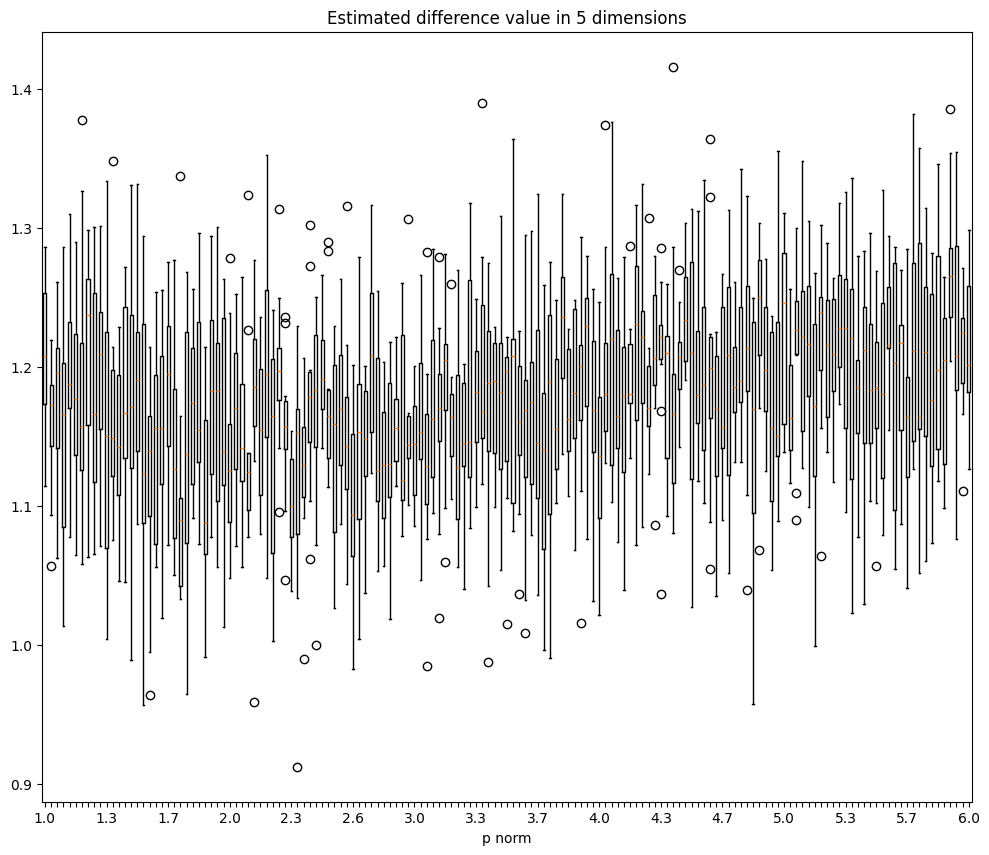

100%|██████████| 1000/1000 [00:00<00:00, 1218920.08it/s]


p=Max -> 1.2339245200539977


100%|██████████| 1000/1000 [00:00<00:00, 165481.89it/s]


p=2 -> 1.141424559737465

Dimension: 6, p_values: 1.0-6.0


100%|██████████| 360/360 [00:00<00:00, 164464.59it/s]


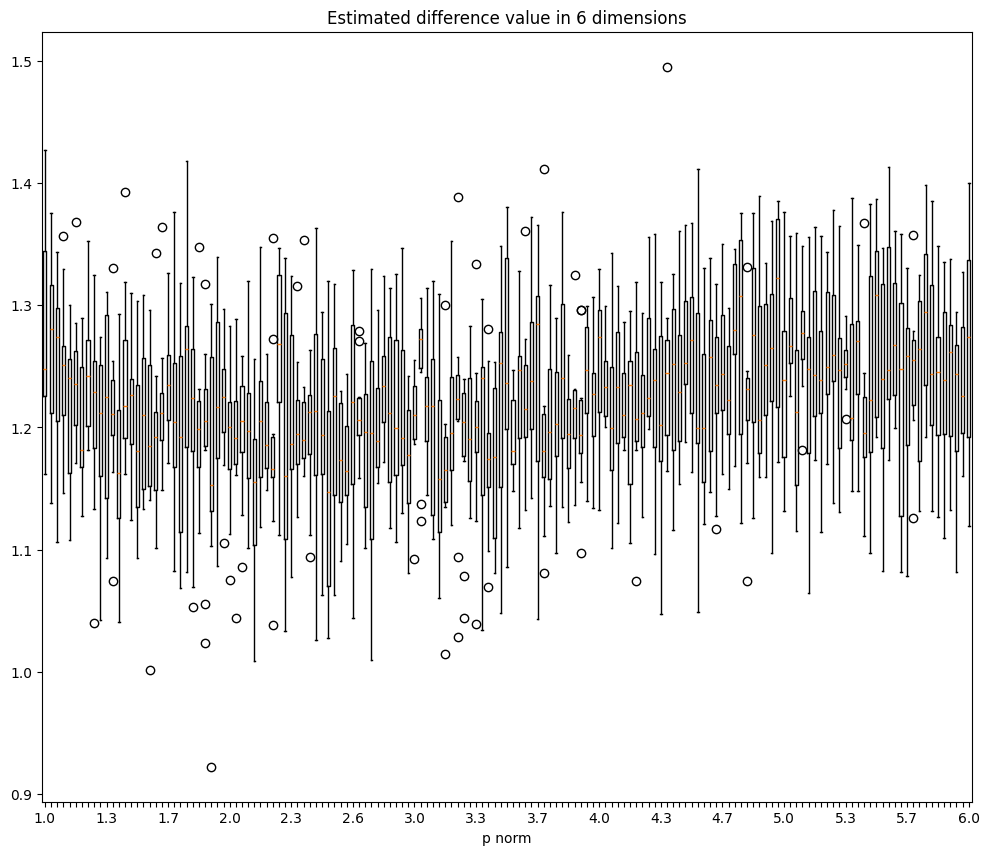

100%|██████████| 1000/1000 [00:00<00:00, 1061043.26it/s]


p=Max -> 1.3246117368853294


100%|██████████| 1000/1000 [00:00<00:00, 62390.17it/s]


p=2 -> 1.1816326364828698

Dimension: 7, p_values: 1.0-6.0


100%|██████████| 360/360 [00:00<00:00, 156585.03it/s]


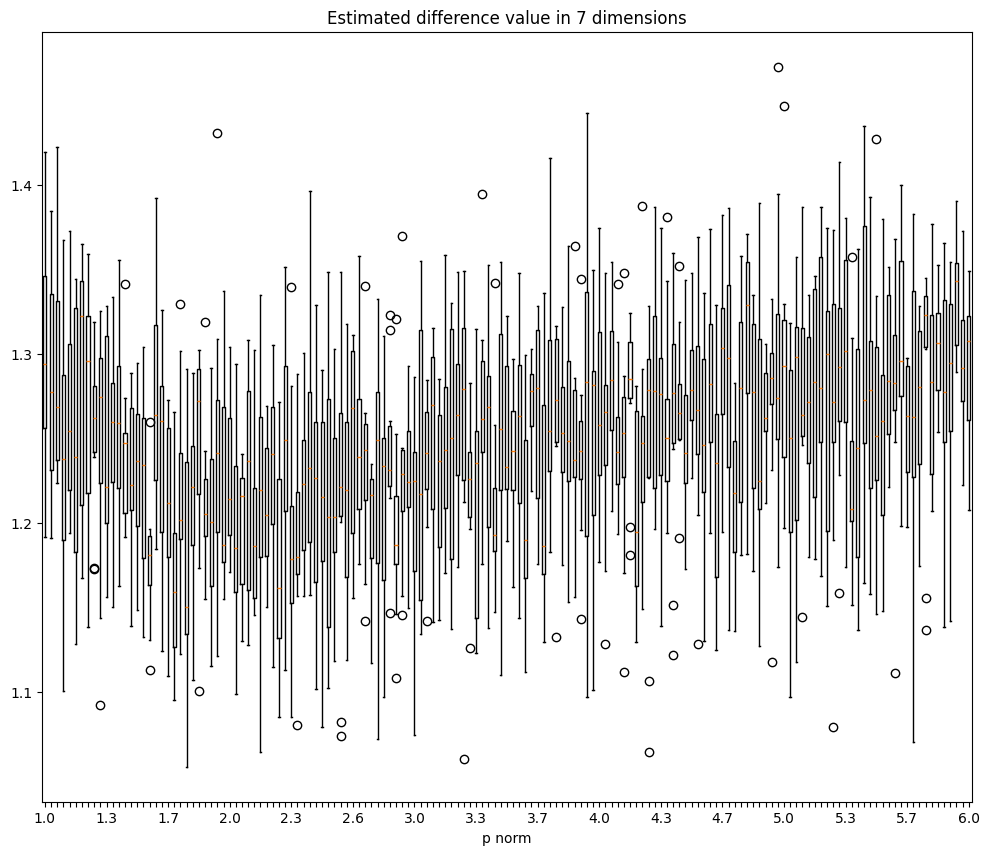

100%|██████████| 1000/1000 [00:00<00:00, 1333218.05it/s]


p=Max -> 1.3405346466224344


100%|██████████| 1000/1000 [00:00<00:00, 34823.69it/s]


p=2 -> 1.2310846966113471

Dimension: 8, p_values: 1.0-6.0


100%|██████████| 360/360 [00:00<00:00, 116275.18it/s]


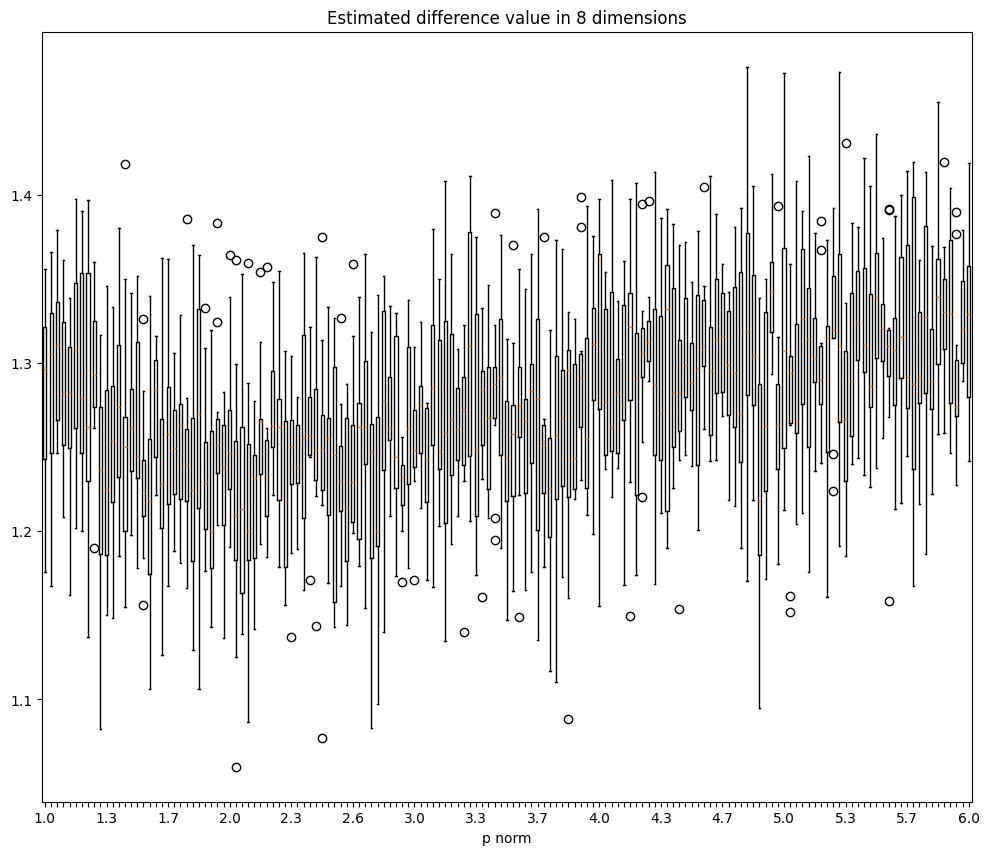

100%|██████████| 1000/1000 [00:00<00:00, 2634613.07it/s]


p=Max -> 1.393691839080005


100%|██████████| 1000/1000 [00:00<00:00, 20334.05it/s]


p=2 -> 1.2442055204627376

Dimension: 9, p_values: 1.0-6.0


100%|██████████| 360/360 [00:00<00:00, 119410.79it/s]


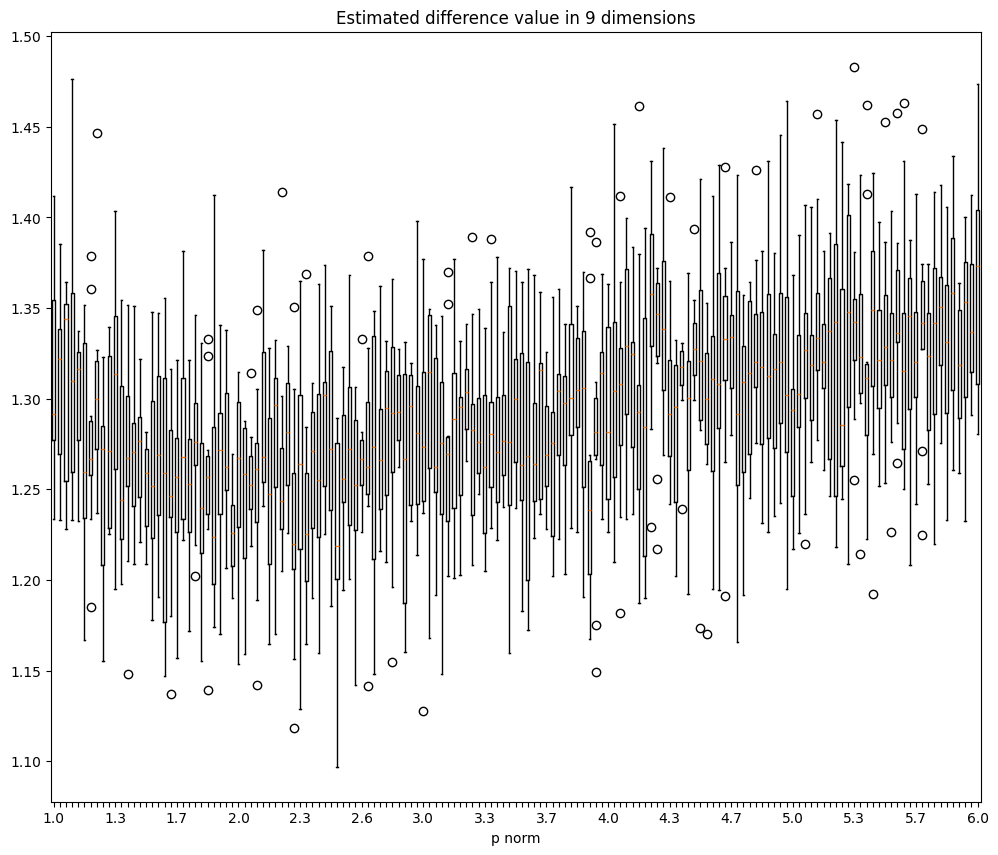

100%|██████████| 1000/1000 [00:00<00:00, 3685680.14it/s]


p=Max -> 1.466281672423309


100%|██████████| 1000/1000 [00:00<00:00, 5981.75it/s]

p=2 -> 1.2505430758584704


In [7]:

number_of_samples = 35
repeats = 10

p_values = dims_linspace(1, 6, 150)
for dimensions in range(1,10):
    print_delimiter()
    print()
    print(f"Dimension: {dimensions}, p_values: {p_values[0]}-{p_values[-1]}")
    generate_plot_against_p(number_of_samples=number_of_samples, dimensions=dimensions, repeats=repeats, p_values=p_values)
    print(f"p=Max -> {estimated_difference_value(repeats, dimensions, p_norm=float('inf'), repeats=100).mean()}")
    print(f"p=2 -> {estimated_difference_value(repeats, dimensions, p_norm=2, repeats=100).mean()}")

# runtime ~ <1 minutes



# Calculating $E[||X-Y||_p]$ for increasing dimensions
#  $n\uparrow$

In [8]:
def generate_plot_against_n(estimated_difference_callback: Callable, dims_array: Iterable):
    result_estimates = np.array([
        estimated_difference_callback(dimensions=dimensions)
        for dimensions in dims_array
    ])
    plt.figure()
    plt.boxplot(result_estimates.T, tick_labels=[f"{dimensions}" for dimensions in dims_array], showmeans=True, showfliers=True, showbox=True)
    plt.show()



Norm: 1, dims_array: 1-10


100%|██████████| 100/100 [09:46<00:00,  5.86s/it]


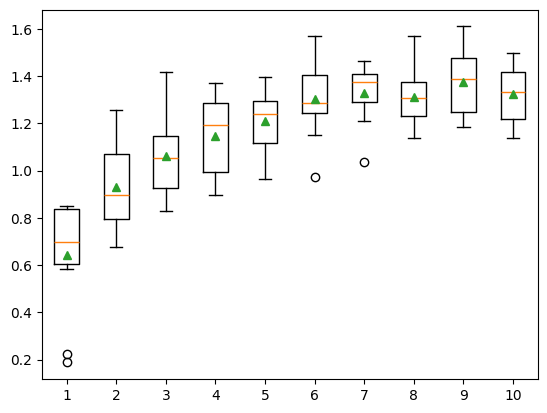



Norm: 2, dims_array: 1-10


100%|██████████| 100/100 [00:00<00:00, 1160.04it/s]


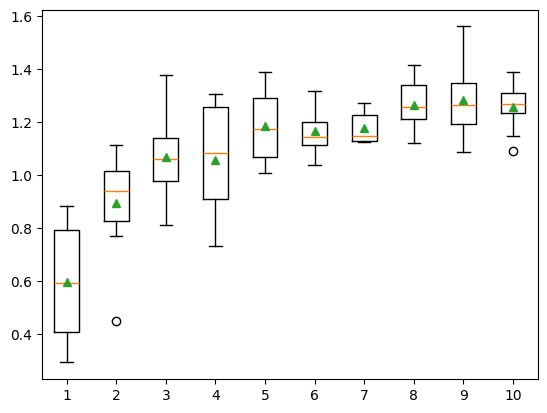



Norm: inf, dims_array: 1-10


100%|██████████| 100/100 [00:00<00:00, 751667.38it/s]


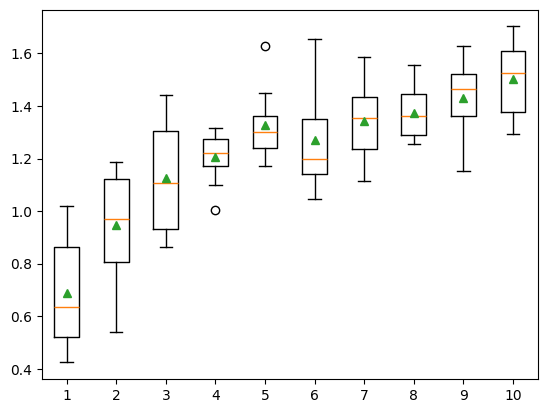

In [14]:
number_of_samples = 10
repeats = 5
dims_array = range(1, 11)

for p_norm in (1, 2, float('inf')):
    print_delimiter()
    print()
    print(f"Norm: {p_norm}, dims_array: {dims_array[0]}-{dims_array[-1]}")
    generate_plot_against_n(partial(estimated_difference_value, number_of_samples=number_of_samples, p_norm=p_norm, repeats=repeats), dims_array=dims_array)
    print(flush=True)

# runtime ~ <30 minutes

# Value of $p$ Norm for random points $x\in\mathbb{R}^n$

In [10]:
import matplotlib.pyplot as plt

def probability_falling_into_unit_ball_probability(dimension: int, p_ord = 2, number_of_samples: int = 10) -> float:

    def p_norm(_vec):
        """calculates (||vec||_p)"""
        return np.linalg.norm(_vec, ord=p_ord, axis=-1)

    sample_vec = random_sample(number_of_samples * dimension).reshape((number_of_samples, dimension))

    probability_unit_ball = (p_norm(sample_vec) <= 1.0).mean()
    return probability_unit_ball


def sample_random_points_norm_on_uniform_square_sidelength2(dimension: int, p_ord = 2, repeats: int = 10) -> np.ndarray:
    sample_vec = random_sample(repeats * dimension).reshape((repeats, dimension))
    return np.linalg.norm(sample_vec, ord=p_ord, axis=-1)


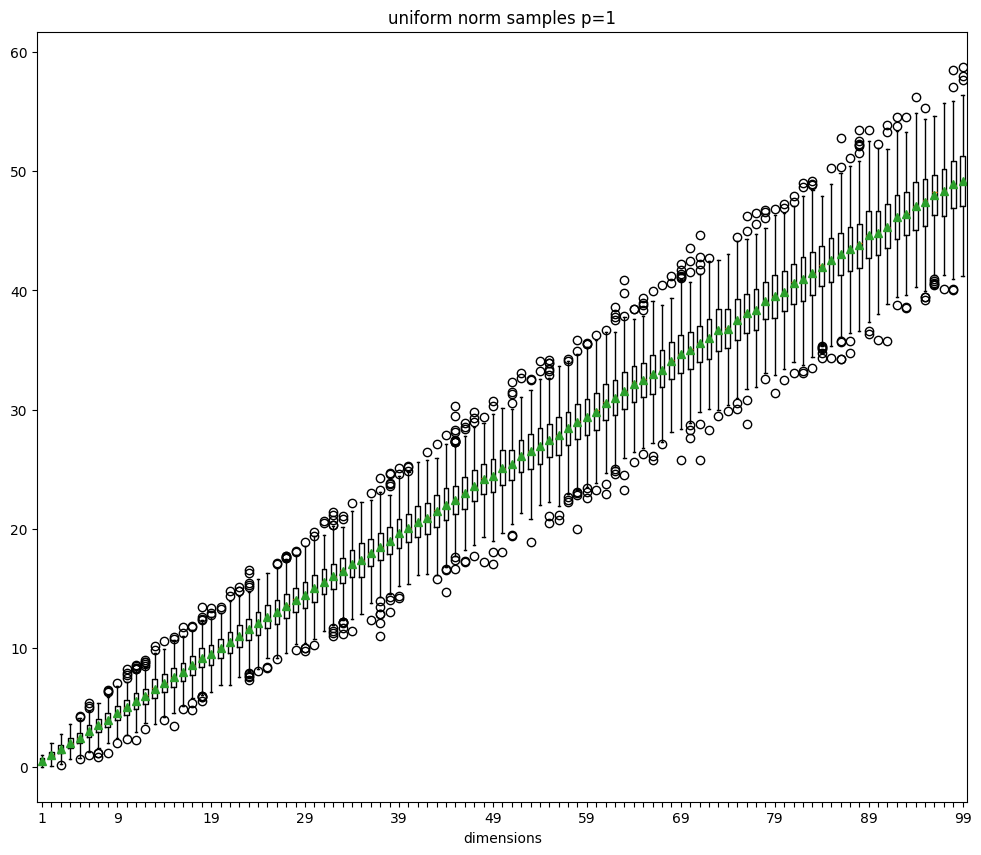

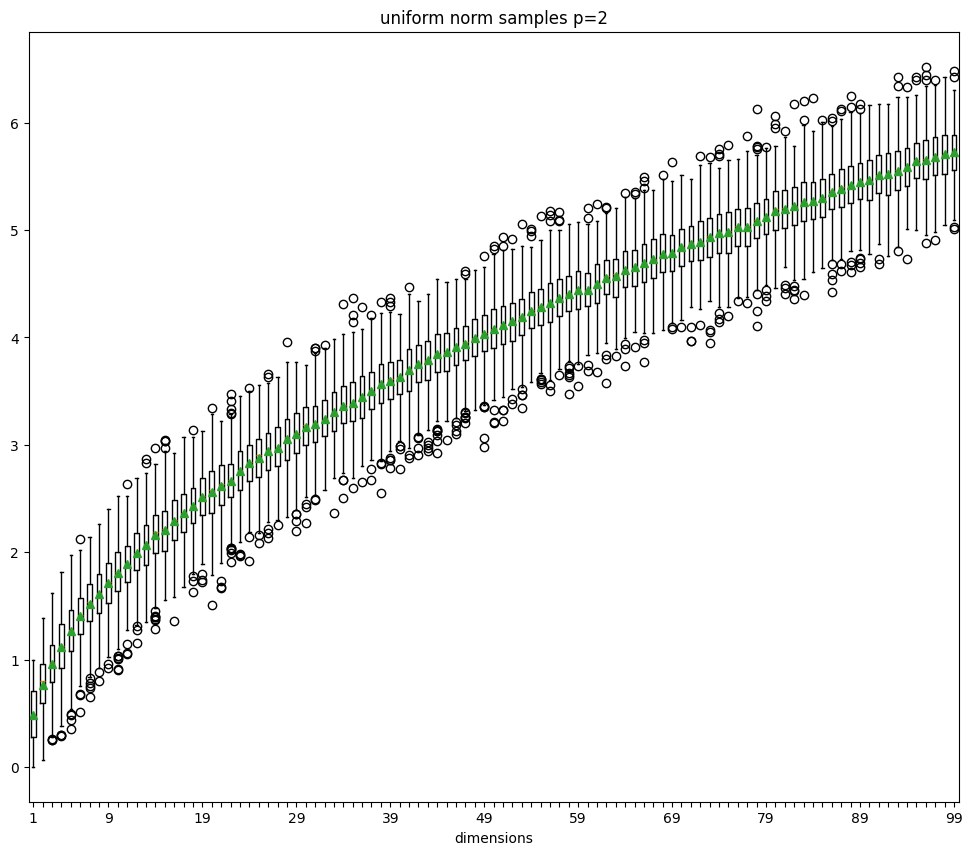

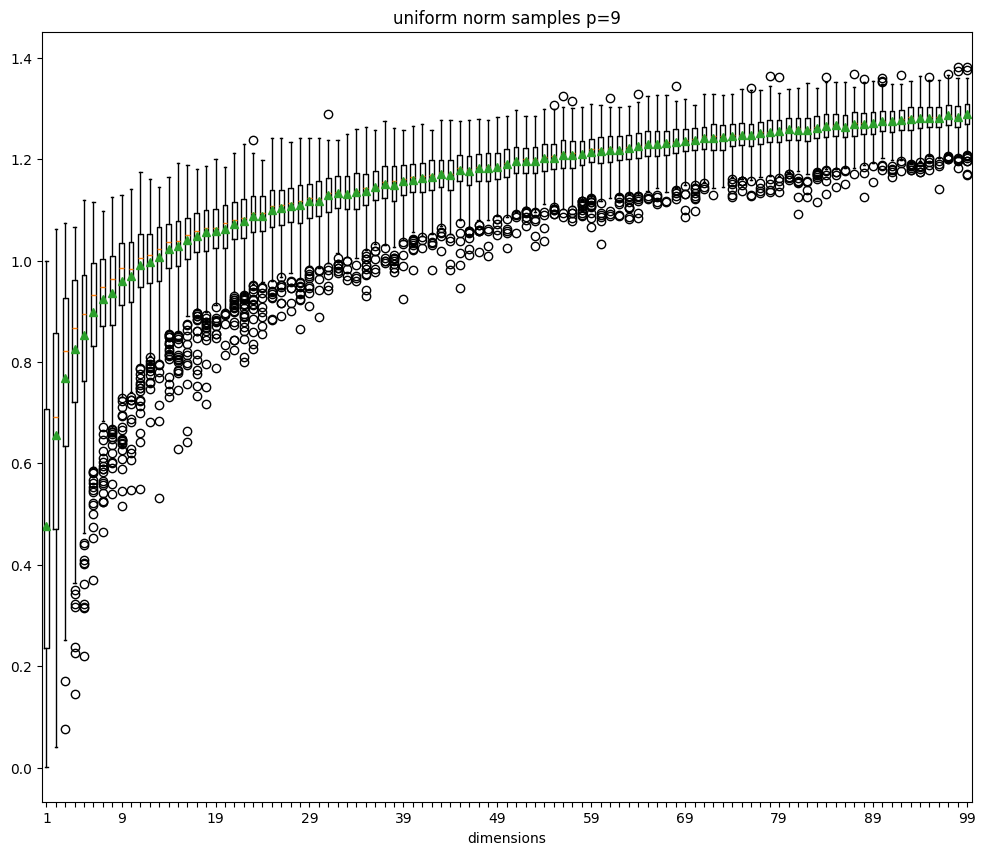

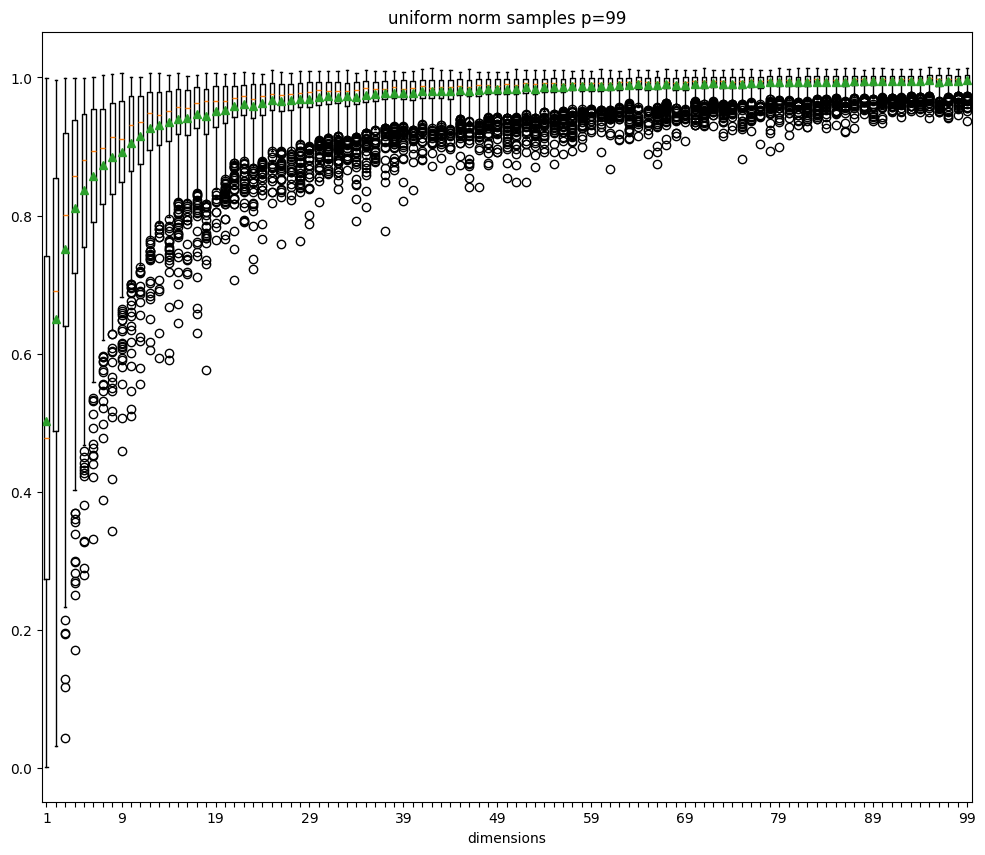

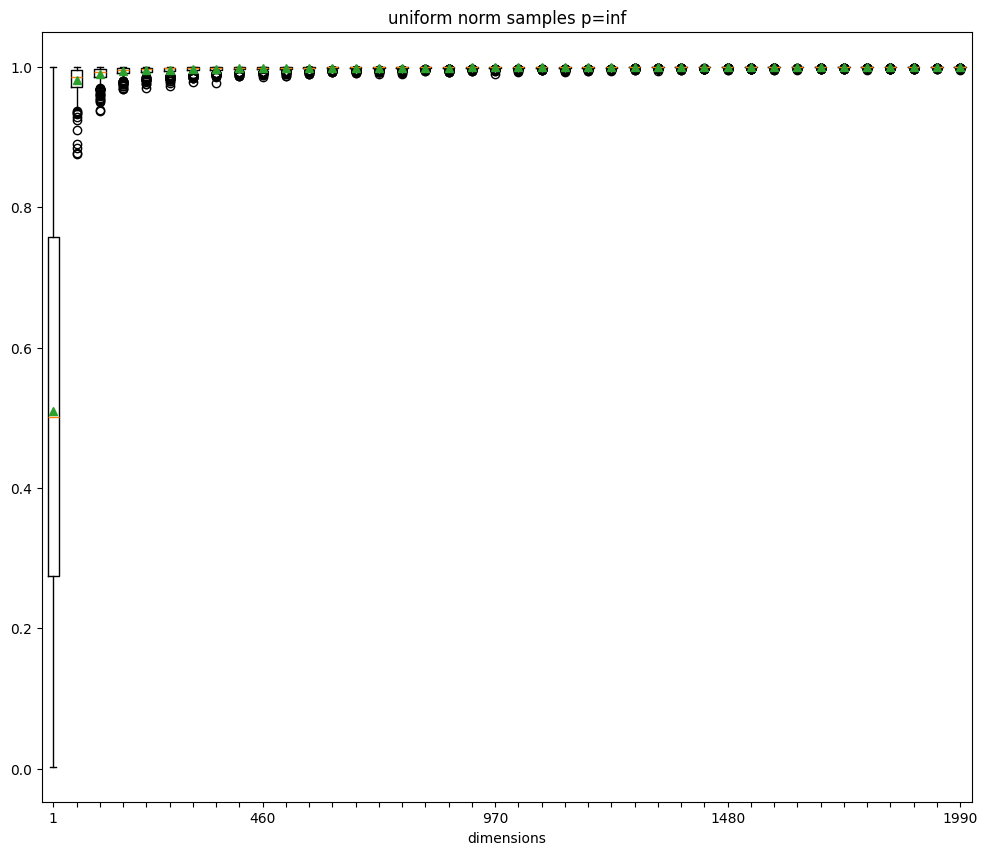

In [11]:

repeats=500
number_of_samples=1000
for (dims_array, p_norm) in (
        (range(1,100), 1),
        (range(1,100), 2),
        (range(1,100), 9),
        (range(1,100), 99),
        (range(1, 2001, 51), np.inf),
):
    plt.figure(figsize=(12, 10))
    plt.title(f"uniform norm samples p={p_norm}")
    plt.xlabel("dimensions")
    estimates = [sample_random_points_norm_on_uniform_square_sidelength2(dimension, p_ord=p_norm, repeats=repeats) for dimension in dims_array]
    plt.boxplot(estimates, showmeans=True, tick_labels=[dims if dims % 10 == dims_array[-1] % 10 or dims == dims_array[0] or dims == dims_array[-1] else "" for dims in dims_array])
    plt.show()


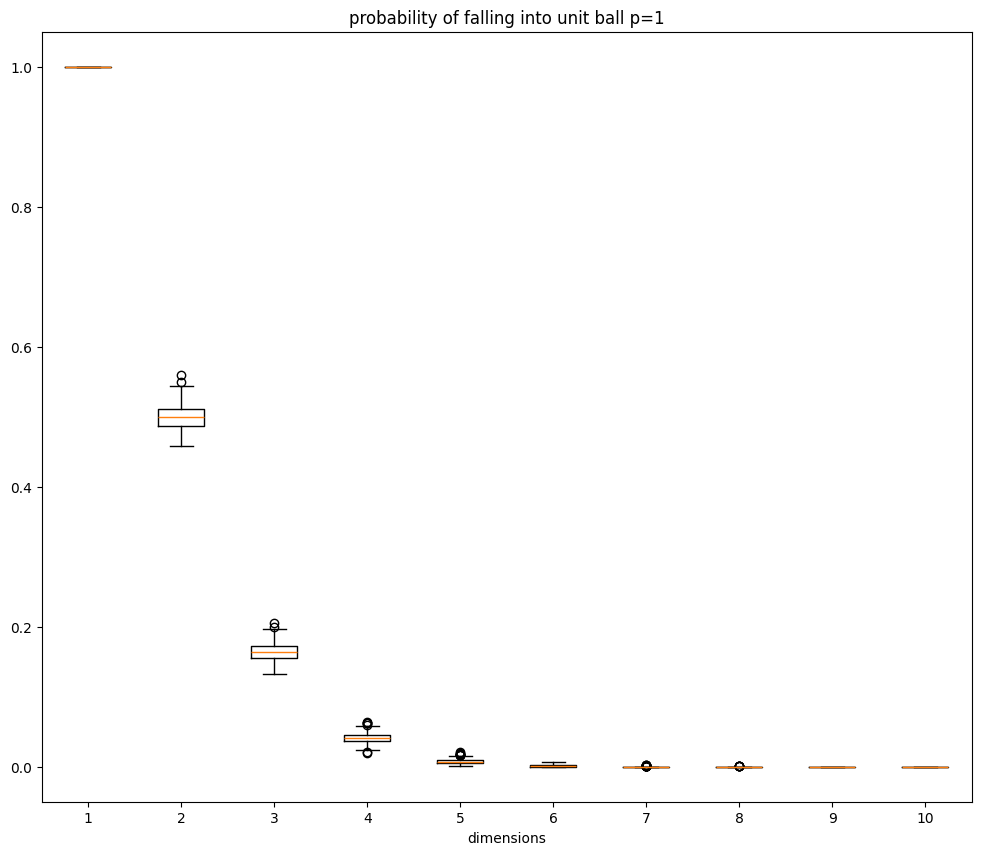

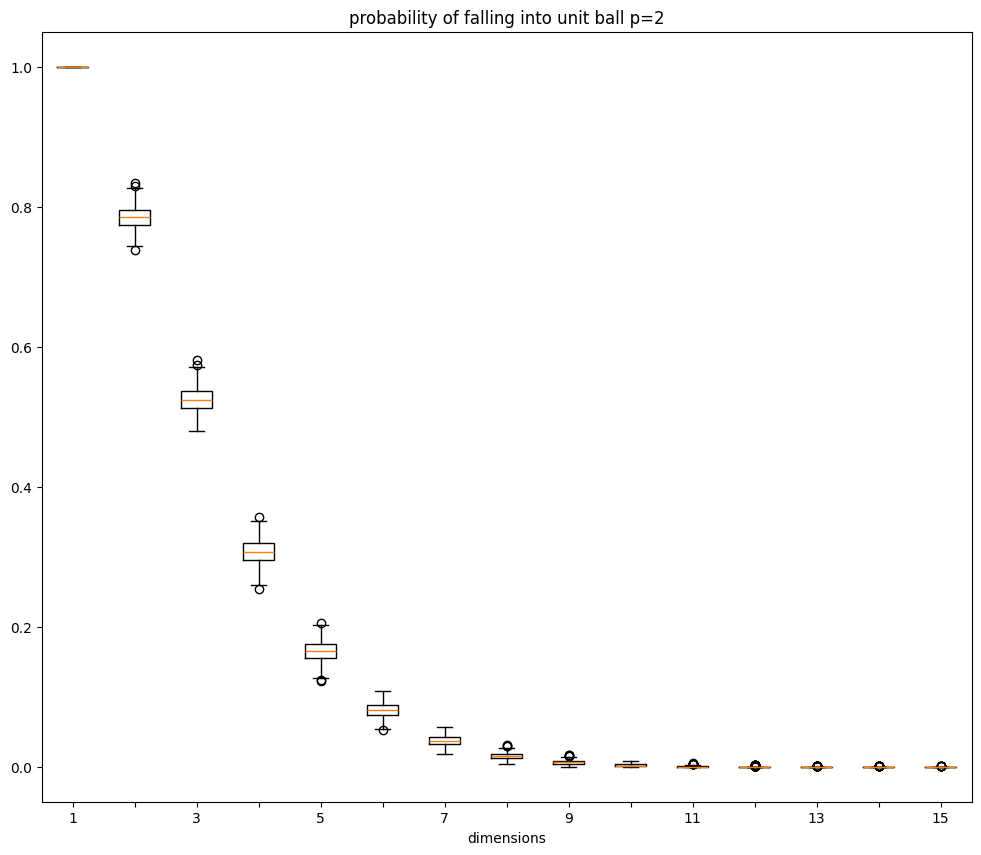

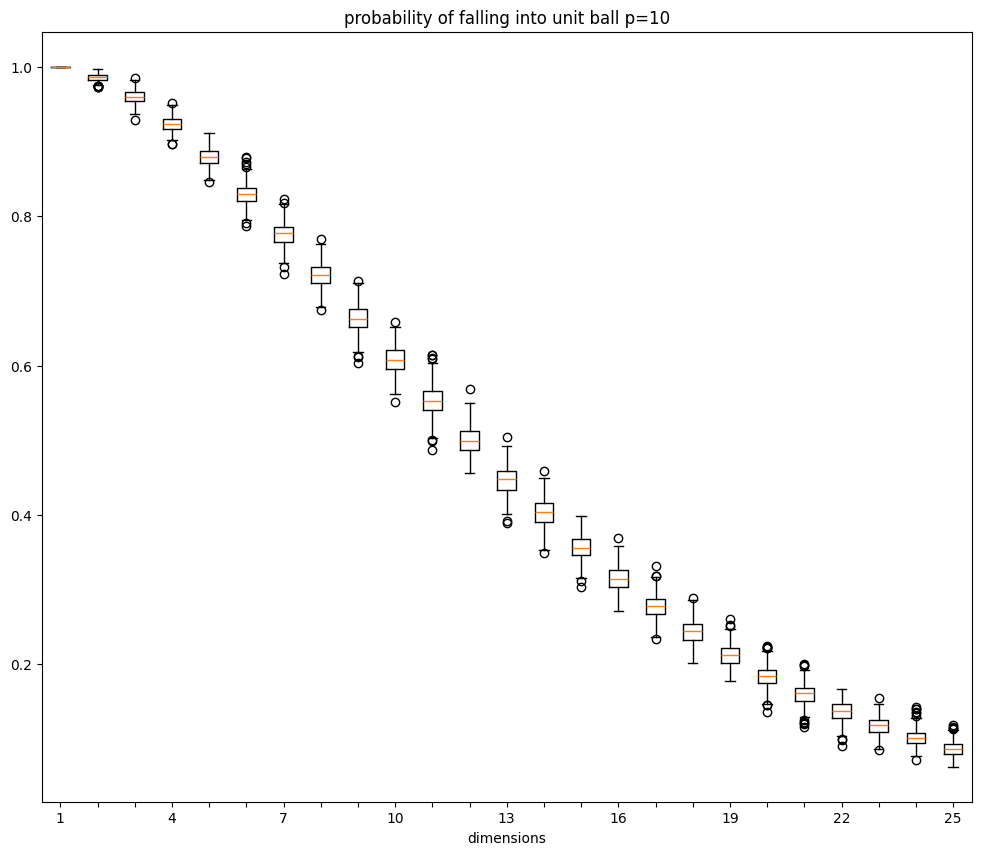

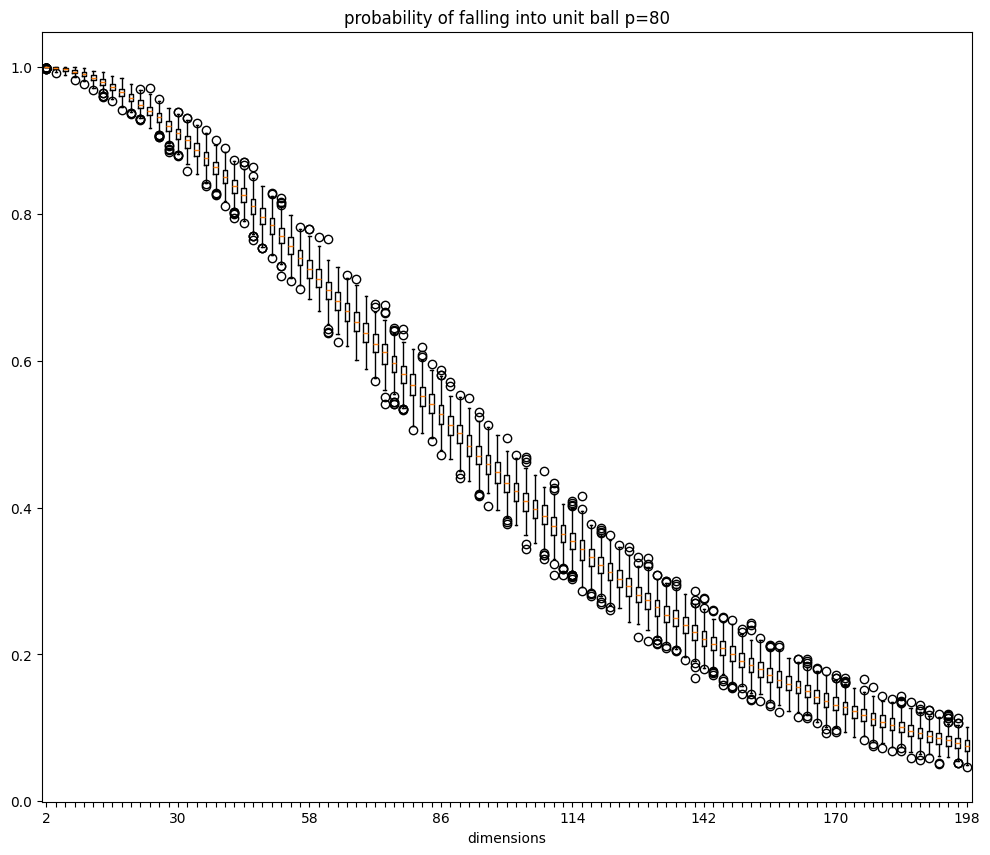

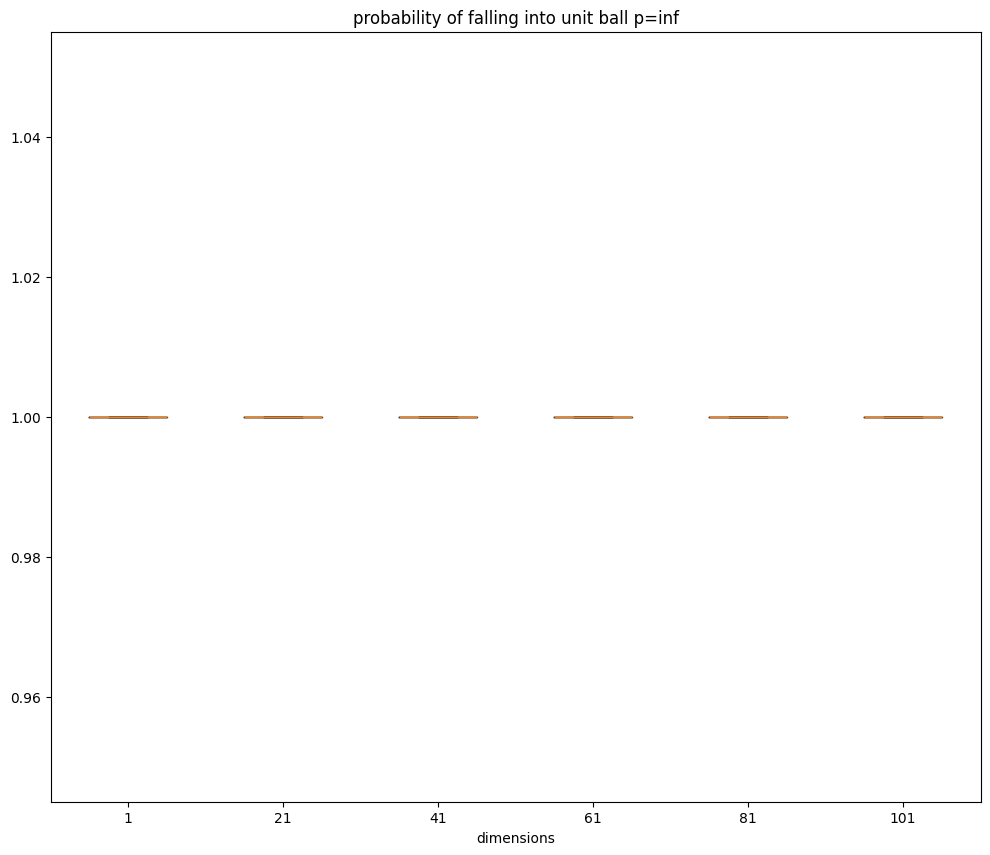

In [12]:

from itertools import chain

repeats=400
number_of_samples=700
for (dims_array, p_norm) in (
        (range(1,11), 1),
        (range(1,16), 2),
        (range(1,26), 10),
        (range(2,200,2), 80),
        (range(1,102,20), np.inf),
):
    plt.figure(figsize=(12, 10))
    plt.title(f"probability of falling into unit ball p={p_norm}")
    plt.xlabel("dimensions")
    estimates = [[probability_falling_into_unit_ball_probability(dimension, p_ord=p_norm, number_of_samples=number_of_samples) for _ in range(repeats)] for dimension in dims_array]
    tick_labels = [dims if idx % max(1, int(0.15*len(dims_array))) == 0 or idx == len(dims_array) - 1 or idx == 0 else "" for idx, dims in enumerate(dims_array)]
    plt.boxplot(x=estimates, tick_labels=tick_labels)
    plt.show()
